In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv('loan_data.csv')
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [30]:
df.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


In [31]:
df.dtypes

,0
credit.policy,int64
purpose,object
int.rate,float64
installment,float64
log.annual.inc,float64
dti,float64
fico,int64
days.with.cr.line,float64
revol.bal,int64
revol.util,float64


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [33]:
# setting targets and features
X = df.drop('not.fully.paid', axis=1)
y = df['not.fully.paid']


In [34]:
# make "purpose" into numeric form
X = pd.get_dummies(X, columns=['purpose'], drop_first=True, dtype='int')
X.head()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,1,0,0,0,0
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,1,0,0,0,0,0
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,1,0,0,0,0
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,1,0,0,0,0
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,1,0,0,0,0,0


In [35]:
# scale the values
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

---
## Step 2: EDA

In [36]:
# finding if the classes are balanced

y.value_counts(normalize=True)

,proportion
not.fully.paid,
0,0.839946
1,0.160054


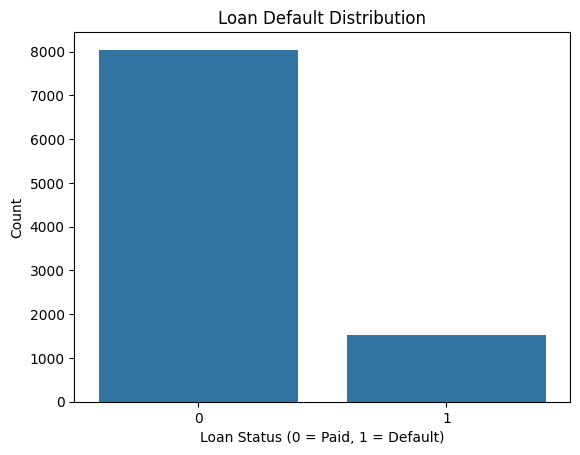

In [37]:
#visualize the class imbalance

sns.countplot(x='not.fully.paid', data=df)
plt.title("Loan Default Distribution")
plt.xlabel("Loan Status (0 = Paid, 1 = Default)")
plt.ylabel("Count")

plt.show()

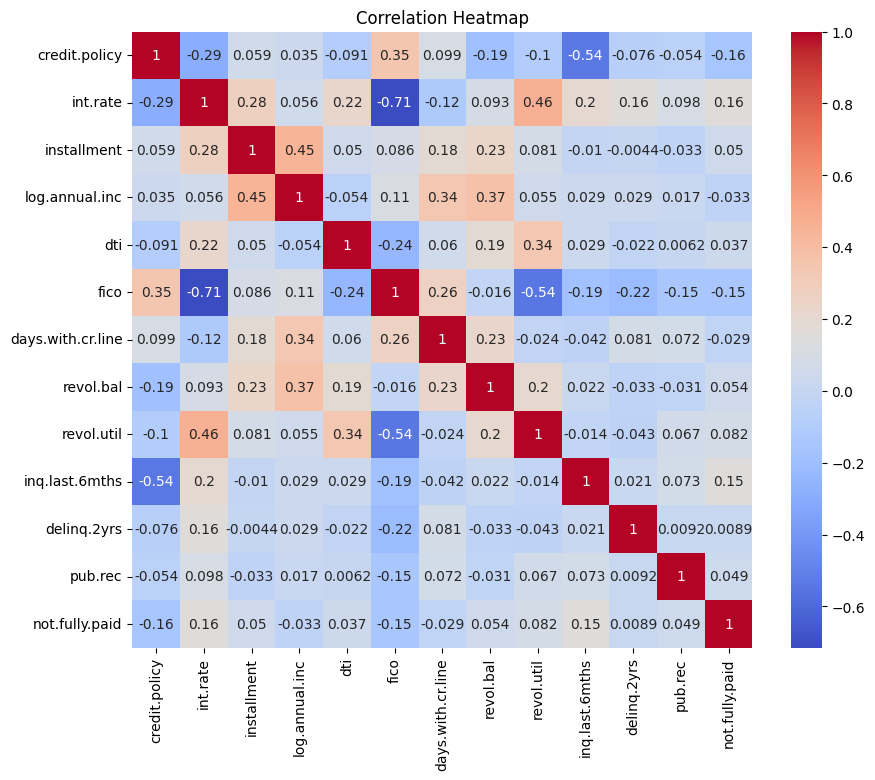

In [38]:
# correlation Heatmap
plt.figure(figsize=(10,8))

corr = df.drop(columns=['purpose']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

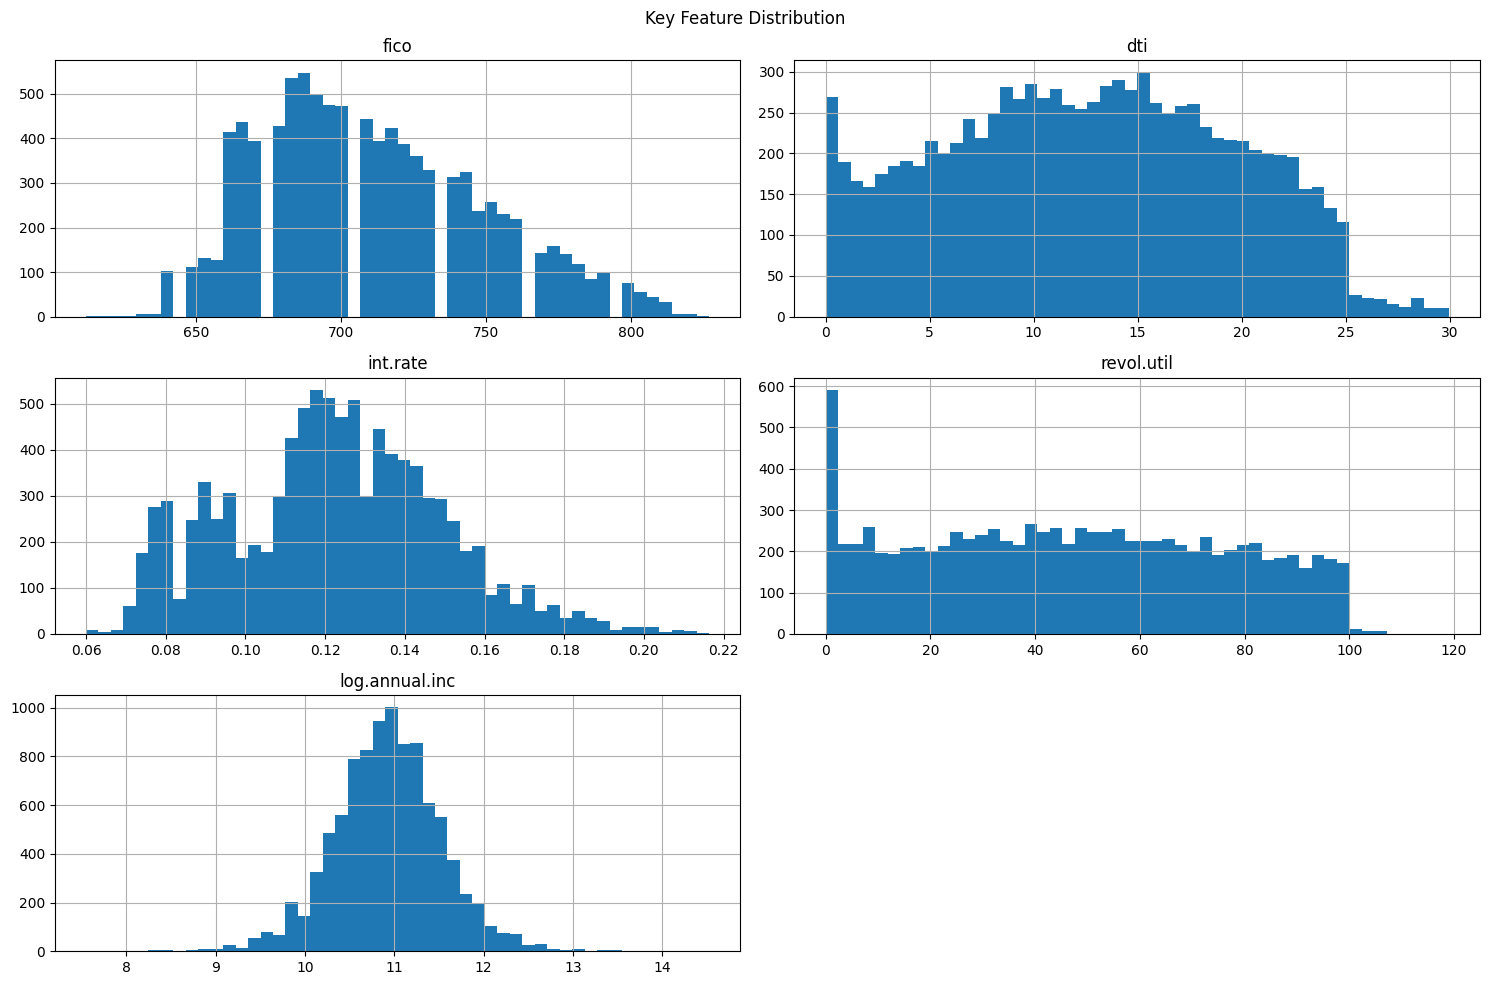

In [39]:
# feature distribution

df[['fico', 'dti', 'int.rate', 'revol.util', 'log.annual.inc']].hist(bins=50, figsize=(15, 10))
plt.suptitle("Key Feature Distribution")
plt.tight_layout()
plt.show()


### feature distribution Summary
- The different histograms show patterns across the different financial attributes
- The FICO graph shows values distributed across the 600's to 800's while showing most borrowers have a moderate to good credit score.
- The DTI shows a wider range of differences between borrowers while the interest rate of people itself is clustered at around 10 to 15 percent.
- These different financial behavious indicators showcase realistic numbers, and they all help to predict if a person will default on a loan

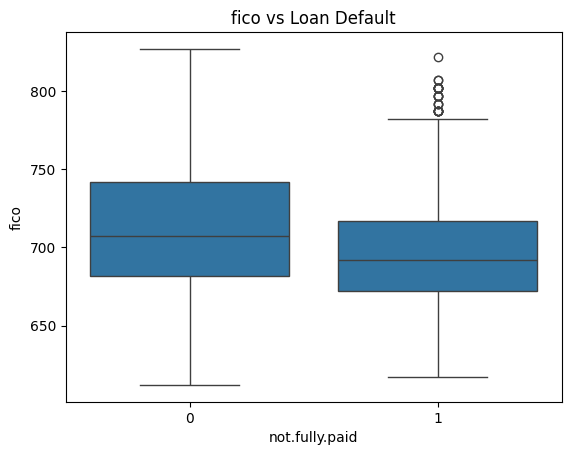

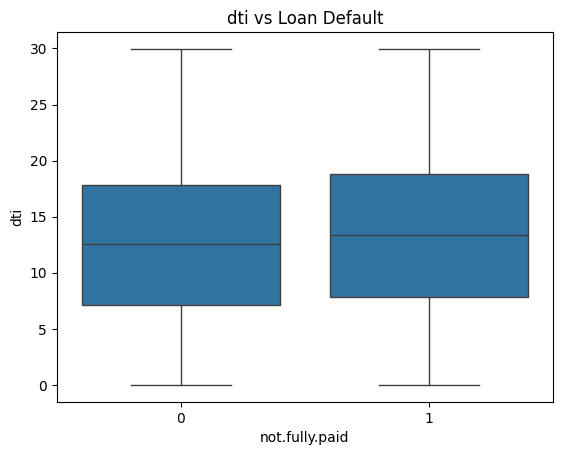

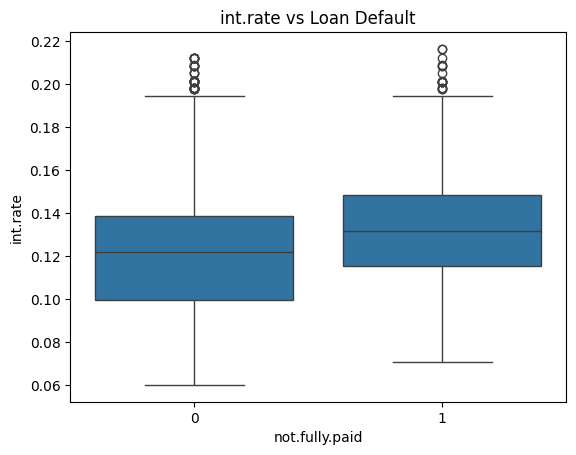

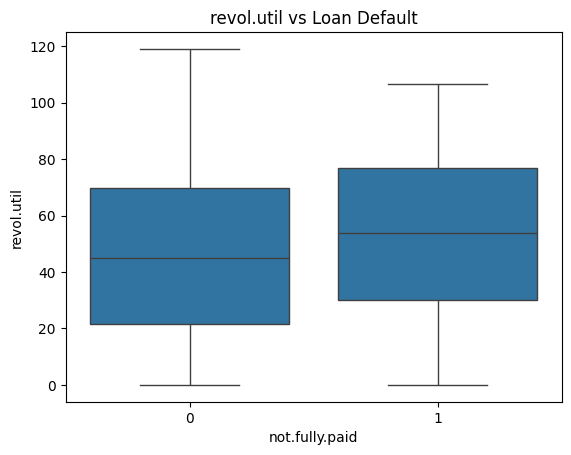

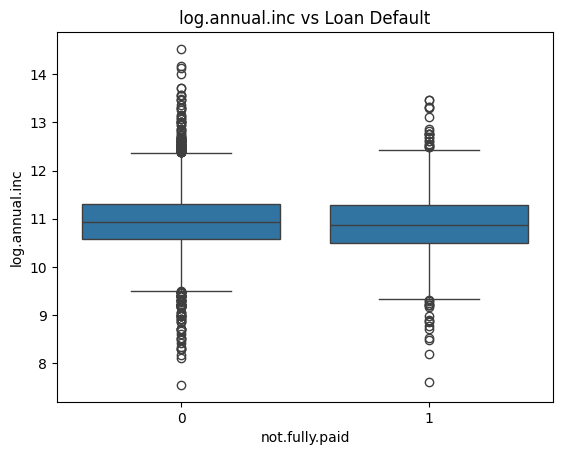

In [40]:
# now to compare default VS non-default

for col in ['fico', 'dti', 'int.rate', 'revol.util', 'log.annual.inc']:
    sns.boxplot(x='not.fully.paid', y=col, data=df)
    plt.title(f"{col} vs Loan Default")
    plt.show()

---
## Step 3: Additional Feature Engineering
- Droping int.rate since it is highly negetivly correlated with FICO score

In [41]:
# dropping int.rate from feature map

X = X.drop(columns=['int.rate'])

---
## Step 4: Model Building

In [44]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [46]:
X_train.shape, X_test.shape

((7662, 18), (1916, 18))

In [47]:
# Building keras neural network
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# compile the model while handling class imbalance
from sklearn.utils.class_weight import compute_class_weight

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)

weights_dict = {0: weights[0], 1: weights[1]}
print(weights_dict)

{0: np.float64(0.5954305253341623), 1: np.float64(3.1197068403908794)}


In [50]:
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, class_weight=weights_dict)

Epoch 1/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5197 - loss: 0.7215 - val_accuracy: 0.6327 - val_loss: 0.6442
Epoch 2/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5878 - loss: 0.6688 - val_accuracy: 0.6080 - val_loss: 0.6332
Epoch 3/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6216 - loss: 0.6575 - val_accuracy: 0.5903 - val_loss: 0.6458
Epoch 4/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5860 - loss: 0.6616 - val_accuracy: 0.5832 - val_loss: 0.6507
Epoch 5/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5987 - loss: 0.6437 - val_accuracy: 0.5982 - val_loss: 0.6379
Epoch 6/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6143 - loss: 0.6423 - val_accuracy: 0.6210 - val_loss: 0.6325
Epoch 7/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6093 - loss: 0.6429 - val_accuracy: 0.6190 - val_loss: 0.6307
Epoch 8/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6001 - loss: 0.6280 - val_accuracy: 0.

In [56]:
#Now lets evaluate the testing data
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

testloss, testacc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {testloss:.4f}")
print(f"Test Accuracy: {testacc:.4f}")

y_pred = model.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred.round()))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred.round()))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_pred)}")


Test Loss: 0.6071
Test Accuracy: 0.6707
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.68      0.78      1611
           1       0.27      0.64      0.38       305

    accuracy                           0.67      1916
   macro avg       0.59      0.66      0.58      1916
weighted avg       0.81      0.67      0.71      1916

Confusion Matrix:
 [[1090  521]
 [ 110  195]]

ROC AUC Score: 0.7041751890181234


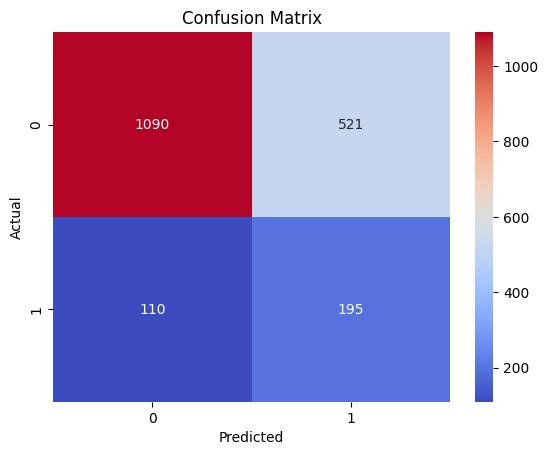

In [65]:
y_pred_class = (y_pred > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.show()


## Sumarizing the findings
- We had to develop a deep learning neural network model to predict loan defaults of borrowers using financial data using loan lending data.
- The set was highly imbalanced, with significantly fewer loans defaulting than being fully repaid.
- Initially performed EDA to help understand the financial feature distribution and relationships/correlation between features
- Removed highly correlated feature of the int.rate since it felt redundent with the feature of the FICO scores. This helps to improve model stability and remove redundency.
- to allow for good modeling, I had to utilize class weighting to ensure allowed for more defaulting cases to be recognized, even if it allowed for more innacuracy.
- I evaluated the model using confusion matrix, precision, recall, accuracy, and ROC-AUC to get the best results for the model
- The Model showcased realistic performance with tradeoffs that allow it to catch high risk loans at the cost of false positives.